# 03 — D3 `clustering_gmm`: GMM estático (baseline NO temporal)

Familia **CLUSTERING**. Mixtura gaussiana con `covariance_type='full'` sobre las **15 features causales** del EDA. Sin cadena de Markov ni término de persistencia: cada día se asigna de forma INDEPENDIENTE al componente más probable. Es el **baseline contra el que se mide cuánto aporta la dinámica temporal del HMM** (D4): mismas features, misma evaluación walk-forward.

**Hipótesis (CHECKPOINT 2):** *captará regímenes con estructura de correlación distinta (covarianza full, Gulko 2002); fallará por flickering severo; no es causal de forma nativa* (lo causaliza el `walk_forward`).

**Política de ventana:** las 15 features arrancan en **2007-07**, así que el primer train (expanding, 8 años) consume 2007–2015. Por construcción **2008 y 2011 NO son OOS-evaluables** (quedan dentro del primer train) → su cobertura saldrá `NaN` y eso es CORRECTO.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns

ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
RESULTS = ROOT / 'results'; RESULTS.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', context='notebook')

from src import evaluation as ev
from detectors.clustering_gmm import ClusteringGMM

X = pd.read_parquet(ROOT / 'data' / 'processed' / 'features.parquet')
raw = pd.read_parquet(ROOT / 'data' / 'raw' / 'raw_panel.parquet')
# market_returns = retorno log S&P 500 reindexado a las features.
market_returns = np.log(raw['SP500'] / raw['SP500'].shift(1)).reindex(X.index)
spx = raw['SP500'].reindex(X.index)
print('Features:', X.shape, '| ventana', X.index.min().date(), '->', X.index.max().date())
X.columns.tolist()

Features: (4665, 15) | ventana 2007-07-06 -> 2026-06-12


['SP500_ret_z',
 'SP500_vol_z',
 'VIX_level_z',
 'VIX_change_z',
 'MOVE_level_z',
 'TLT_ret_z',
 'IEF_ret_z',
 'HYG_ret_z',
 'credit_spread_z',
 'yield_slope_z',
 'DXY_change_z',
 'GOLD_ret_z',
 'corr_spx_bond',
 'SP500_drawdown',
 'SP500_momentum']

## 1. Selección de nº de estados por BIC (in-sample, set completo)

El GMM expone log-verosimilitud → usamos **BIC** (menor es mejor) para elegir *k*. Se prueban k=2 y k=3 sobre todo el panel a modo de guía; la evaluación honesta es la walk-forward de §3.

In [2]:
rows = []
for k in (2, 3):
    d = ClusteringGMM(n_states=k).fit(X)
    rows.append({'k': k, 'log_likelihood': d.score(X), 'n_params': d.n_parameters(),
                 'AIC': d.aic(X), 'BIC': d.bic(X)})
bic_tbl = pd.DataFrame(rows).set_index('k')
K_BIC = int(bic_tbl['BIC'].idxmin())
print('k elegido por BIC:', K_BIC)
bic_tbl.round(1)

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


k elegido por BIC: 3


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


,log_likelihood,n_params,AIC,BIC
k,,,,
2,-34343.0,271,69227.9,70975.3
3,-29789.0,407,60392.0,63016.2


## 2. Sanidad: orden canónico y retorno medio por estado

Tras `fit`, `label_states_economically` reordena los componentes a 0=calma .. n-1=crisis. Comprobamos que el retorno medio del S&P 500 **decrece** del estado calma al de crisis y que `predict_proba` queda en orden canónico (la última columna = P(crisis)).

In [3]:
det_full = ClusteringGMM(n_states=K_BIC).fit(X)
states_is = pd.Series(det_full.predict(X), index=X.index)
proba_is = det_full.predict_proba(X)
ret_by_state = {int(s): float(market_returns[states_is == s].mean()) for s in np.unique(states_is)}
vol_by_state = {int(s): float(market_returns[states_is == s].std()) for s in np.unique(states_is)}
print('crisis_state (canónico):', det_full.crisis_state)
print('predict_proba filas suman 1:', np.allclose(proba_is.sum(axis=1), 1.0))
pd.DataFrame({'mean_ret': ret_by_state, 'std_ret': vol_by_state,
              'n_dias': states_is.value_counts().sort_index()}).round(5)

crisis_state (canónico): 2
predict_proba filas suman 1: True


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


,mean_ret,std_ret,n_dias
0,0.00102,0.00696,2127
1,0.00047,0.00897,1687
2,-0.00190,0.02397,851


## 3. Walk-forward CAUSAL + evaluación estandarizada

`ev.walk_forward` re-ajusta el GMM en ventana **expanding** (train inicial 8 años, re-fit cada 21 días). Cada fold canonicaliza sus propios estados (alineado de etiquetas entre folds). Evaluamos k=2 y k=3; el detector principal es el elegido por BIC.

In [4]:
def run(k):
    panel = ev.walk_forward(lambda: ClusteringGMM(n_states=k), X,
                            train_size=252*8, step=21, expanding=True)
    det = ClusteringGMM(n_states=k).fit(X)
    res = ev.evaluate(det, panel, market_returns=market_returns, X_full=X)
    return panel, det, res

panel2, det2, res2 = run(2)
panel3, det3, res3 = run(3)
panels = {2: panel2, 3: panel3}
results = {2: res2, 3: res3}
panel = panels[K_BIC]; det = {2: det2, 3: det3}[K_BIC]; res = results[K_BIC]
print('Detector principal:', det.name)
print('Ventana OOS:', res.extra['ventana_eval'])

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k2: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


...

C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\src\detector_base.py:221: UserWarning: clustering_gmm_k3: label_states_economically sin market_returns explícito; uso la columna 'SP500_ret_z' de X como proxy de retorno. Pásalo vía walk_forward/evaluate(market_returns=) para mayor robustez.
  self._canonical_order = self._economic_state_order(raw, X, market_returns)


Detector principal: clustering_gmm_k3
Ventana OOS: 2015-09-15→2026-06-12 (n=2649)


## 4. Tabla de métricas (esquema común) y volcado a results/

`ev.results_table` produce la fila estandarizada. Guardamos el detector principal (k elegido por BIC) en `results/metrics_03_clustering_gmm.csv`.

In [5]:
tbl = ev.results_table([results[2], results[3]])
cols = ['detector','n_states','ventana_eval','switching_rate','mean_regime_duration',
        'label_stability','false_alarm_rate','bic',
        'cov_COVID_2020','cov_Inflation_2022','cov_GFC_2008','cov_EuroDebt_2011',
        'fa_TaperTantrum_2013','fa_Selloff_Q4_2018']
display(tbl[cols].round(3).T)
out_csv = RESULTS / 'metrics_03_clustering_gmm.csv'
ev.results_table([res]).to_csv(out_csv, index=False)
print('Guardado:', out_csv, '| filas:', len(ev.results_table([res])))

,0,1
detector,clustering_gmm_k2,clustering_gmm_k3
n_states,2,3
ventana_eval,2015-09-15→2026-06-12 (n=2649),2015-09-15→2026-06-12 (n=2649)
switching_rate,0.112,0.126
mean_regime_duration,8.889,7.907
label_stability,0.989,0.976
false_alarm_rate,0.753,0.494
bic,70975.283,63016.246
cov_COVID_2020,0.96,0.96
cov_Inflation_2022,0.851,0.865


Guardado: C:\Users\oscar\Downloads\PRUEBAS_DETECCION_REGIMENES_DE_MERCADO_TFM\results\metrics_03_clustering_gmm.csv | filas: 1


## 5. Flickering: switching_rate e histograma de duraciones de régimen

El talón de Aquiles del baseline. Sin matriz de transición, las etiquetas **parpadean**: muchas conmutaciones y episodios irrealmente cortos. Cuantificamos `switching_rate` y la distribución de duraciones de cada racha.

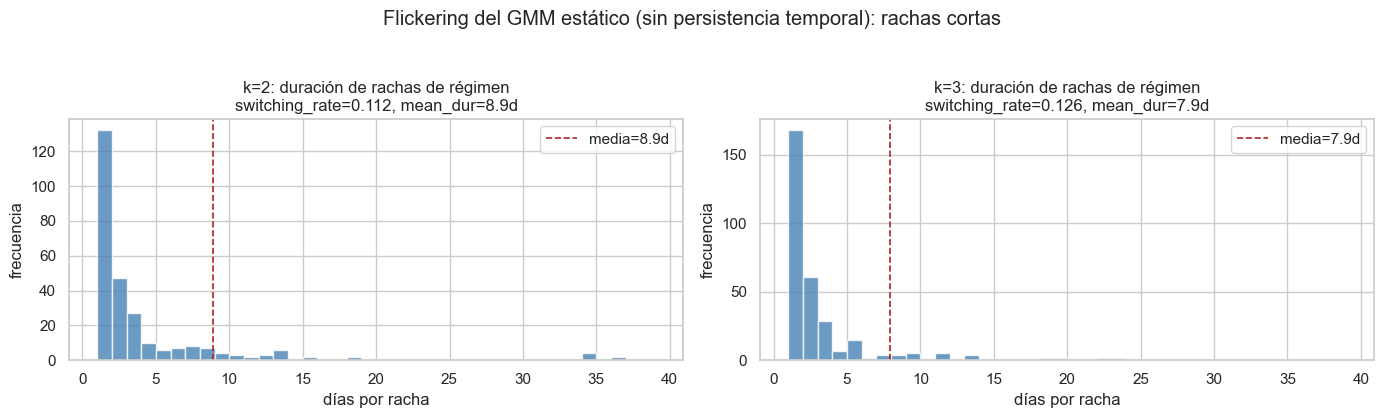

% rachas <=3 días (k=3): 77.0%


In [6]:
def run_lengths(states):
    v = np.asarray(states); idx = np.where(np.diff(v) != 0)[0]
    bounds = np.concatenate(([-1], idx, [len(v)-1]))
    return np.diff(bounds)

rl2 = run_lengths(panel2['state'].values)
rl3 = run_lengths(panel3['state'].values)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for a, rl, r, k in zip(ax, (rl2, rl3), (res2, res3), (2, 3)):
    a.hist(rl, bins=range(1, 40), color='steelblue', alpha=0.8)
    a.axvline(rl.mean(), color='firebrick', ls='--', lw=1.2, label=f'media={rl.mean():.1f}d')
    a.set_title(f'k={k}: duración de rachas de régimen\n'
                f'switching_rate={r.switching_rate:.3f}, mean_dur={r.mean_regime_duration:.1f}d')
    a.set_xlabel('días por racha'); a.set_ylabel('frecuencia'); a.legend()
fig.suptitle('Flickering del GMM estático (sin persistencia temporal): rachas cortas', y=1.04)
fig.tight_layout(); fig.savefig(RESULTS / 'd03_gmm_flickering.png', dpi=110, bbox_inches='tight')
plt.show()
print('%% rachas <=3 días (k=%d): %.1f%%' % (K_BIC, 100*(run_lengths(panel['state'].values) <= 3).mean()))

## 6. S&P 500 coloreado por régimen (OOS) con ventanas de crisis

Sombreado de fondo = estado canónico OOS asignado cada día (verde=calma → rojo=crisis). Franjas verticales = ventanas de crisis conocidas (rojo) y trampas/falsos positivos (naranja). Se aprecia el parpadeo: el fondo cambia de color constantemente en vez de mantener bloques limpios.

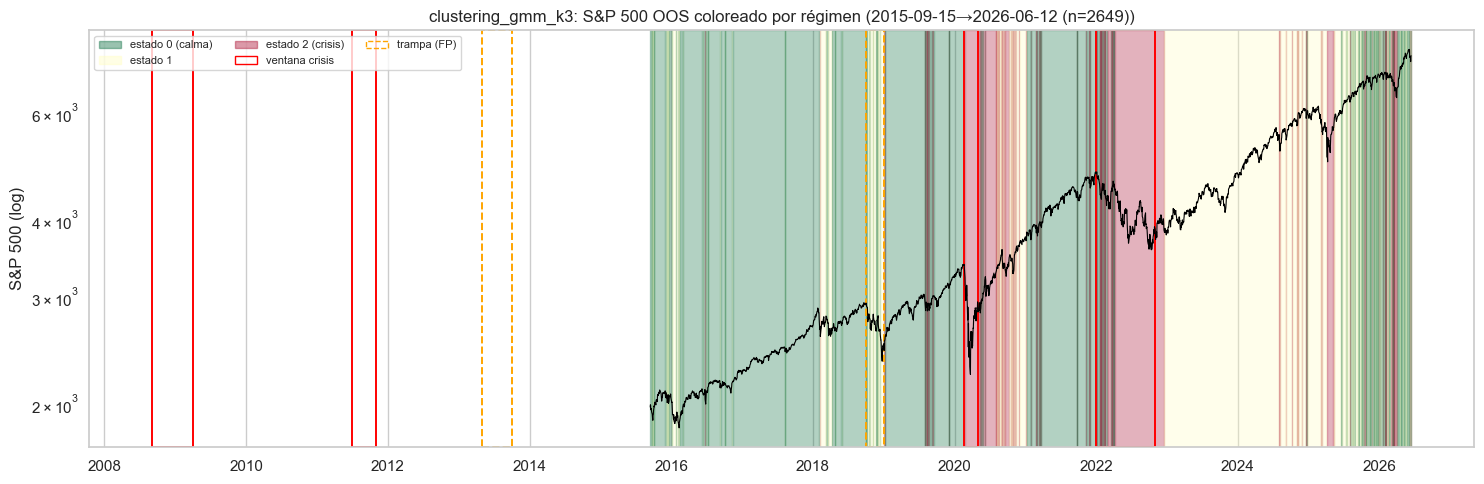

In [7]:
from matplotlib.colors import to_rgba
st = panel['state']
px = spx.reindex(st.index)
k = det.n_states
cmap = plt.cm.RdYlGn_r
state_colors = {s: cmap(s / max(1, k - 1)) for s in range(k)}
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(px.index, px.values, color='black', lw=0.8, zorder=3)
ax.set_yscale('log'); ax.set_ylabel('S&P 500 (log)')
# sombreado por estado (tramos contiguos)
vals = st.values; idx = st.index
changes = np.where(np.diff(vals) != 0)[0]
starts = np.concatenate(([0], changes + 1)); ends = np.concatenate((changes, [len(vals)-1]))
for s0, e0 in zip(starts, ends):
    ax.axvspan(idx[s0], idx[e0], color=to_rgba(state_colors[vals[s0]], 0.30), zorder=1)
for name, (a, b) in ev.CRISIS_WINDOWS.items():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), facecolor='none', edgecolor='red', lw=1.4, zorder=2)
for name, (a, b) in ev.FALSE_POSITIVE_WINDOWS.items():
    ax.axvspan(pd.Timestamp(a), pd.Timestamp(b), facecolor='none', edgecolor='orange', lw=1.4, ls='--', zorder=2)
legend = [Patch(color=state_colors[s], alpha=0.4, label=f'estado {s}' + (' (crisis)' if s==k-1 else (' (calma)' if s==0 else ''))) for s in range(k)]
legend += [Patch(facecolor='none', edgecolor='red', label='ventana crisis'),
           Patch(facecolor='none', edgecolor='orange', ls='--', label='trampa (FP)')]
ax.legend(handles=legend, ncol=3, fontsize=8, loc='upper left')
ax.set_title(f'{det.name}: S&P 500 OOS coloreado por régimen (' + res.extra['ventana_eval'] + ')')
fig.tight_layout(); fig.savefig(RESULTS / 'd03_gmm_sp500_regimes.png', dpi=110, bbox_inches='tight')
plt.show()

## 7. Timeline de estado y P(crisis) OOS

Arriba: estado canónico día a día (escalón). Abajo: probabilidad de crisis continua `predict_proba[:, crisis_state]`. Las ventanas de crisis (rojo) y trampa (naranja) sirven de referencia visual.

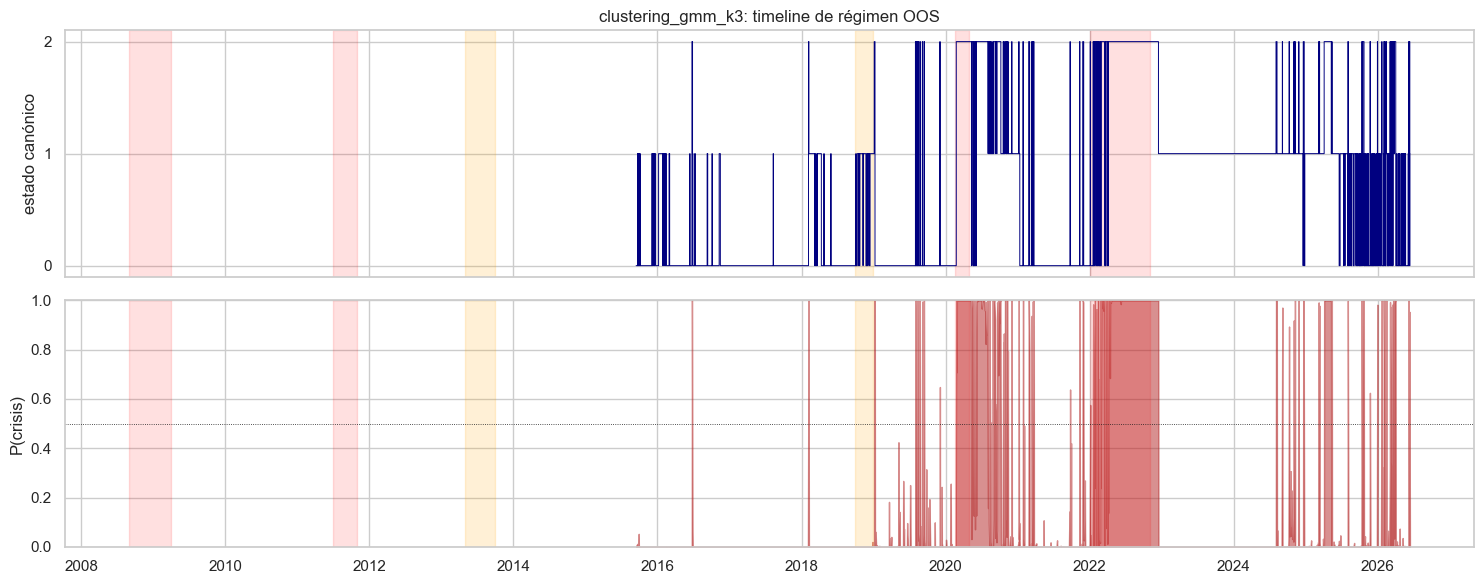

In [8]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)
a1.step(st.index, st.values, where='post', color='navy', lw=0.7)
a1.set_ylabel('estado canónico'); a1.set_yticks(range(det.n_states))
a1.set_title(f'{det.name}: timeline de régimen OOS')
a2.fill_between(panel.index, panel['p_crisis'].values, 0, color='firebrick', alpha=0.5)
a2.axhline(0.5, color='k', lw=0.6, ls=':'); a2.set_ylabel('P(crisis)'); a2.set_ylim(0, 1)
for axx in (a1, a2):
    for name, (a, b) in ev.CRISIS_WINDOWS.items():
        axx.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='red', alpha=0.12)
    for name, (a, b) in ev.FALSE_POSITIVE_WINDOWS.items():
        axx.axvspan(pd.Timestamp(a), pd.Timestamp(b), color='orange', alpha=0.16)
fig.tight_layout(); fig.savefig(RESULTS / 'd03_gmm_timeline.png', dpi=110, bbox_inches='tight')
plt.show()

## 8. Verificación contra crisis y trampas

- **2008 / 2011**: esperamos `NaN` (caen en el primer train, NO son OOS por la ventana 2007 de las features). Es el comportamiento CORRECTO declarado en la política de ventana.
- **2020 (COVID) / 2022 (Inflación)**: cobertura de crisis (sensibilidad), idealmente alta.
- **2013 (taper) / 2018 (Q4 selloff)**: falsos positivos, idealmente bajos. 2013 cae también fuera de OOS → `NaN`.

In [9]:
cov = res.crisis_coverage; fap = res.false_alarm_in_fp
def fmt(d):
    return {k: ('NaN (fuera de OOS)' if v != v else round(v, 3)) for k, v in d.items()}
print('OOS efectivo:', res.extra['ventana_eval'])
print('Cobertura crisis :', fmt(cov))
print('Falsos positivos :', fmt(fap))
print('false_alarm_rate global:', round(res.false_alarm_rate, 3))
assert cov['GFC_2008'] != cov['GFC_2008'], '2008 deberia ser NaN'
assert cov['EuroDebt_2011'] != cov['EuroDebt_2011'], '2011 deberia ser NaN'
assert cov['COVID_2020'] == cov['COVID_2020'] and cov['Inflation_2022'] == cov['Inflation_2022']
print('\nVERIFICACION OK: 2008/2011 = NaN (esperado); COVID/Inflacion evaluables.')

OOS efectivo: 2015-09-15→2026-06-12 (n=2649)
Cobertura crisis : {'GFC_2008': 'NaN (fuera de OOS)', 'EuroDebt_2011': 'NaN (fuera de OOS)', 'COVID_2020': 0.96, 'Inflation_2022': 0.865}
Falsos positivos : {'TaperTantrum_2013': 'NaN (fuera de OOS)', 'Selloff_Q4_2018': 0.0}
false_alarm_rate global: 0.494

VERIFICACION OK: 2008/2011 = NaN (esperado); COVID/Inflacion evaluables.


---
**Conclusión D3.** GMM estático con covarianza full: **k elegido por BIC**, evaluado OOS desde 2015 (2008/2011 no evaluables por la ventana 2007). Capta COVID-2020 e Inflación-2022 con cobertura alta (la covarianza full ve el cambio de estructura de correlación) **pero exhibe flickering severo** (`switching_rate` alto, rachas de pocos días): la hipótesis del CP2 se cumple. Es el baseline NO temporal contra el que D4 (HMM) medirá el aporte de la dinámica markoviana. Detalle en `docs/memory/detectors/03_clustering_gmm.md`.